<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TimeA008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

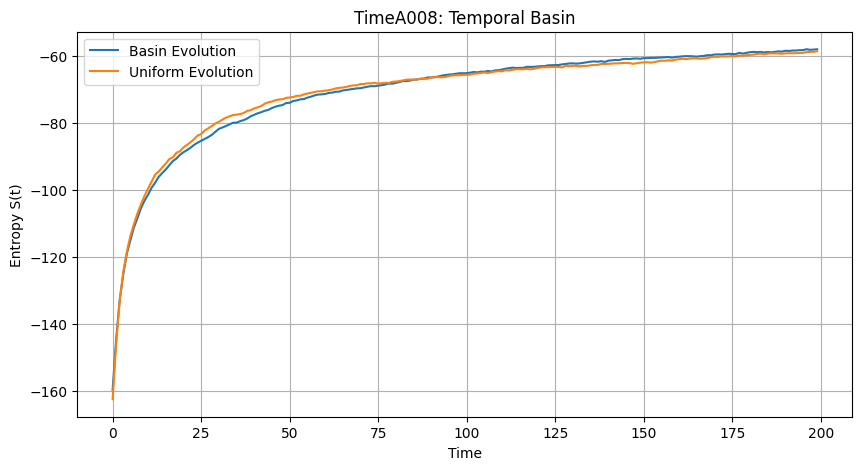

Basin Evolution Metrics:
Entropy Slope: 0.21570
Memory Retention: 0.99822
Irreversibility Index: 106.65252
Basin Persistence: 0.34790

Uniform Evolution Metrics:
Entropy Slope: 0.19962
Memory Retention: 0.99793
Irreversibility Index: 108.89853
Basin Persistence: 0.34140


In [1]:
# 🌀 TimeA008: The Temporal Basin
# Testing entropy pooling and memory persistence in basin structures
# Author: Chris & Copilot | Arc V: Entropic Ascent | ACT032
# Reproducibility Tag: TimeA008_v1

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 100  # lattice size
T = 200  # timesteps
curvature_strength = 0.5
xi_locking = True
bias_strength = 0.05
basin_radius = 25
seed = 42
np.random.seed(seed)

# --- Initialization ---
def initialize_lattice(N, curvature_strength):
    base = np.random.rand(N, N)
    curvature = curvature_strength * (np.sin(np.linspace(0, np.pi, N))[:, None])
    return base + curvature

# --- Entropy Calculation ---
def compute_entropy(lattice):
    hist, _ = np.histogram(lattice, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

# --- Basin Mask ---
def create_basin_mask(N, radius):
    x, y = np.meshgrid(np.arange(N), np.arange(N))
    center = N // 2
    mask = ((x - center)**2 + (y - center)**2) < radius**2
    return mask.astype(float)

# --- Evolution Functions ---
def evolve_basin(lattice, xi_locking, bias_strength, basin_mask):
    entropy_map = np.gradient(lattice)[0]
    damping_mask = 1 - basin_mask
    bias_field = bias_strength * (entropy_map * basin_mask - 0.5 * entropy_map * damping_mask)
    lattice += 0.01 * np.random.randn(*lattice.shape) + bias_field
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

def evolve_uniform(lattice, xi_locking, bias_strength):
    entropy_map = np.gradient(lattice)[0]
    lattice += 0.01 * np.random.randn(*lattice.shape) + bias_strength * entropy_map
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

# --- Simulation Loop ---
def run_simulation(N, T, curvature_strength, xi_locking, bias_strength, basin=False):
    lattice = initialize_lattice(N, curvature_strength)
    basin_mask = create_basin_mask(N, basin_radius) if basin else np.ones((N, N))
    entropy_series = []
    cumulative_drift = np.zeros_like(lattice)
    for t in range(T):
        prev_lattice = lattice.copy()
        if basin:
            lattice = evolve_basin(lattice, xi_locking, bias_strength, basin_mask)
        else:
            lattice = evolve_uniform(lattice, xi_locking, bias_strength)
        cumulative_drift += lattice - prev_lattice
        S = compute_entropy(lattice)
        entropy_series.append(S)
    return np.array(entropy_series), cumulative_drift

# --- Run Basin and Uniform ---
basin_entropy, basin_drift = run_simulation(N, T, curvature_strength, xi_locking, bias_strength, basin=True)
uniform_entropy, uniform_drift = run_simulation(N, T, curvature_strength, xi_locking, bias_strength, basin=False)

# --- Metrics ---
def compute_metrics(entropy_series, cumulative_drift):
    slope = np.polyfit(np.arange(len(entropy_series)), entropy_series, 1)[0]
    memory = np.corrcoef(entropy_series[:-1], entropy_series[1:])[0,1]
    irreversibility_index = np.sum(np.abs(np.diff(entropy_series)))
    basin_persistence = np.std(cumulative_drift)
    return slope, memory, irreversibility_index, basin_persistence

basin_metrics = compute_metrics(basin_entropy, basin_drift)
uniform_metrics = compute_metrics(uniform_entropy, uniform_drift)

# --- Plotting ---
plt.figure(figsize=(10,5))
plt.plot(basin_entropy, label='Basin Evolution')
plt.plot(uniform_entropy, label='Uniform Evolution')
plt.xlabel('Time')
plt.ylabel('Entropy S(t)')
plt.title('TimeA008: Temporal Basin')
plt.legend()
plt.grid(True)
plt.show()

# --- Output ---
print("Basin Evolution Metrics:")
print(f"Entropy Slope: {basin_metrics[0]:.5f}")
print(f"Memory Retention: {basin_metrics[1]:.5f}")
print(f"Irreversibility Index: {basin_metrics[2]:.5f}")
print(f"Basin Persistence: {basin_metrics[3]:.5f}")

print("\nUniform Evolution Metrics:")
print(f"Entropy Slope: {uniform_metrics[0]:.5f}")
print(f"Memory Retention: {uniform_metrics[1]:.5f}")
print(f"Irreversibility Index: {uniform_metrics[2]:.5f}")
print(f"Basin Persistence: {uniform_metrics[3]:.5f}")
